In this file we produce synthetic network (Erdos-Renyi and Scale Free) data.
We then remove nodes w/ associated links following a 
1. uniform distribution over the nodes;
2. higher k priority attack.

We then plot (as measure of network failure) the **diameter** against the **fraction of removed nodes f** as weel as **relative size of largest cluster S** and **avg size of isolated clusters \<s\>** against **f**. 


We expect to find the same results as the Albert, Jeong, Barabàsi "Error and attck tolerance of complex networks" Fig.2,3.

**PLAN**
1. Choose metrics to be plotted against (f)
    * S
    * \<s\>
    * avg diameter
    * other metrics (might be **model specific**)
2. Choose network generation models + for each model we vary the parameters
    * E-R
    * Scale Free (a bit vague, there are many models inside)
    * Barabasi-Albert
    * Attractivness Model
    * Random walk model
3. Choose attack type
    * Random in grade
    * Remove highest grade first
    * Remove highest *insert metric here* first
    * (STUPID IDEA) Maybe attack following a probability distribution over k?????
4. Analyze **Metrics vs f** for each model and metric to get insights on robustness.

In [2]:
import random
import networkx as nx
import math
from time import time
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
############################################
########### function to get <s> ############
############################################

def s_avg(G):
    comps=[]
    G_copy=G.copy()

    for i in range(nx.number_connected_components(G)):
        largest_cluster = max(nx.connected_components(G_copy), key=len)
        comps.append(len(largest_cluster)) 
        G_copy.remove_nodes_from(largest_cluster)

    if len(comps)-1!=0:
        s = (G.number_of_nodes() - comps[0])/(len(comps)-1)
    else:
        s = 0
        
    return s



# **RANDOM vs ATTACK FAILURE ON ERDOS RENYI**

In [ ]:

N = 5000
p = 0.0007
# since p_c goes like 1/N and we want to simulate an attack on a Gcc, 
# we will choose p>>1/n such that Gcc is present for sue and our "attack" will send us back to the disconnected phase

# f = 0.2

ER_rand = nx.erdos_renyi_graph(N, p)
ER_att = nx.erdos_renyi_graph(N, p)
f = []
S_rand = []
s_rand = []
S_att = []
s_att = []
removed_rand=0
removed_att=0

for q in np.arange(0,1,0.005):

    print(q)
    # build array of f = fraction of removed nodes
    f.append(q)

#### remove f*N nodes at RANDOM ####
    number_remno = int(q * N - removed_rand)
    nodes_to_remove = random.sample(list(ER_rand.nodes()), number_remno)
    ER_rand.remove_nodes_from(nodes_to_remove)
    removed_rand = N - ER_rand.number_of_nodes()
    #print(len(nodes_to_remove),ER.number_of_nodes())


    # calculates size of largest cluster S = (n° nodes in largest cluster) / (n° nodes in network)
    largest_cluster = max(nx.connected_components(ER_rand), key=len)
    S_rand.append(len(largest_cluster) / ER_rand.number_of_nodes())
    s_rand.append(s_avg(ER_rand))


#### remove f*N nodes via ATTACK ####
    ordered_nodes = [node for node, deg in sorted(ER_att.degree,key=lambda x: x[1],reverse=True)]

    number_remno = int(q * N - removed_att)
    ER_att.remove_nodes_from(ordered_nodes[:number_remno])
    removed_att = N - ER_att.number_of_nodes()

    # calculates size of largest cluster S = (n° nodes in largest cluster) / (n° nodes in network)
    largest_cluster = max(nx.connected_components(ER_att), key=len)
    S_att.append(len(largest_cluster) / ER_att.number_of_nodes())
    s_att.append(s_avg(ER_att))






0.0
0.005
0.01
0.015
0.02
0.025
0.03
0.035
0.04
0.045
0.05
0.055
0.06
0.065
0.07
0.075
0.08
0.085
0.09
0.095
0.1
0.105
0.11
0.115
0.12
0.125
0.13
0.135
0.14
0.145
0.15
0.155
0.16
0.165
0.17
0.17500000000000002
0.18
0.185
0.19
0.195
0.2
0.20500000000000002
0.21
0.215
0.22
0.225
0.23
0.23500000000000001
0.24
0.245
0.25
0.255
0.26
0.265
0.27
0.275
0.28
0.28500000000000003
0.29
0.295
0.3
0.305
0.31
0.315
0.32
0.325
0.33
0.335
0.34
0.34500000000000003
0.35000000000000003
0.355
0.36
0.365
0.37
0.375
0.38
0.385
0.39
0.395
0.4
0.405
0.41000000000000003
0.41500000000000004
0.42
0.425
0.43
0.435
0.44
0.445
0.45
0.455
0.46
0.465
0.47000000000000003
0.47500000000000003
0.48
0.485
0.49
0.495
0.5
0.505
0.51
0.515
0.52
0.525
0.53
0.535
0.54
0.545
0.55
0.555
0.56
0.5650000000000001
0.5700000000000001
0.5750000000000001
0.58
0.585
0.59
0.595
0.6
0.605
0.61
0.615
0.62
0.625
0.63
0.635
0.64
0.645
0.65
0.655
0.66
0.665
0.67
0.675
0.68
0.685
0.6900000000000001
0.6950000000000001
0.7000000000000001
0.705
0.

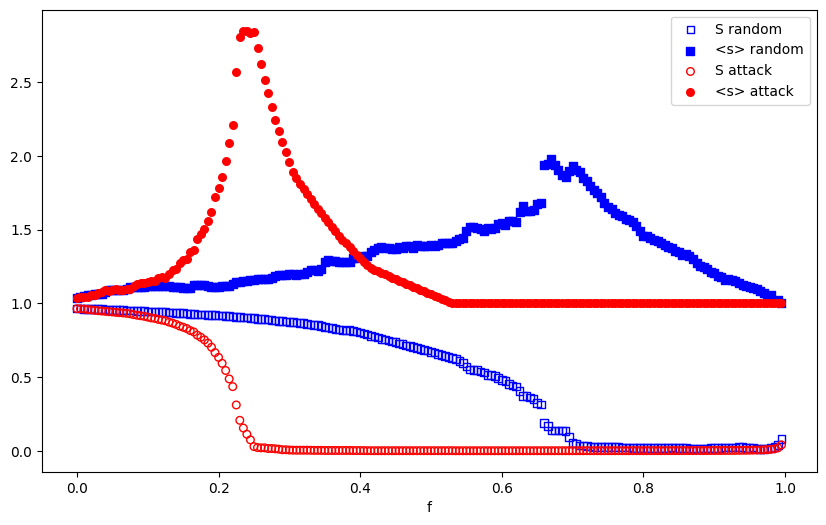

In [15]:
plt.figure(1, figsize=(10, 6))
plt.scatter(f,S_rand,s=30, marker="s",facecolors="none",edgecolors="blue", label="S random")
plt.scatter(f,s_rand,s=30, marker="s", facecolors="blue", label="<s> random")
plt.scatter(f,S_att,s=30, marker="o",facecolors="none",edgecolors="red", label="S attack")
plt.scatter(f,s_att,s=30, marker="o", facecolors="red", label="<s> attack")
plt.xlabel("f")

plt.legend()

plt.show()

## Here we do the same but taking the average
This requires many runs hence there are some slight optimisations and changes to the code

0
1
2


<ErrorbarContainer object of 3 artists>

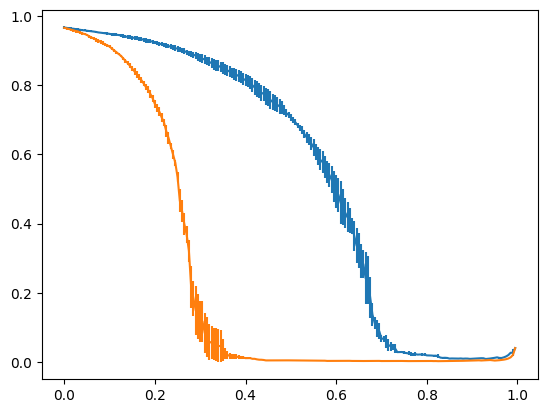

In [ ]:
N_runs=3

N = 5000
p = 0.0007
# since p_c goes like 1/N and we want to simulate an attack on a Gcc, 
# we will choose p>>1/n such that Gcc is present for sue and our "attack" will send us back to the disconnected phase

# f = 0.2

q_values = np.arange(0, 1, 0.005)
N_q = len(q_values)

f = q_values

S_rand_all = np.zeros((N_runs,N_q)) 
s_rand_all = np.zeros((N_runs,N_q))
S_att_all = np.zeros((N_runs,N_q))
s_att_all = np.zeros((N_runs,N_q))


for run in range(N_runs):

    ER_rand = nx.erdos_renyi_graph(N, p)
    ER_att = nx.erdos_renyi_graph(N, p)

    nodes = list(ER_att.nodes())
    random.shuffle(nodes)

    ordered_nodes = sorted(nodes, key=lambda n: ER_att.degree(n), reverse=True)
    # f = []
    # S_rand = []
    # s_rand = []
    # S_att = []
    # s_att = []
    removed_rand=0
    removed_att=0
    print(run)

    for iq, q in enumerate(q_values):

    #### remove f*N nodes at RANDOM ####
        number_remno = int(q * N - removed_rand)
        nodes_to_remove = random.sample(list(ER_rand.nodes()), number_remno)
        ER_rand.remove_nodes_from(nodes_to_remove)
        removed_rand = N - ER_rand.number_of_nodes()
        #print(len(nodes_to_remove),ER.number_of_nodes())


        # calculates size of largest cluster S = (n° nodes in largest cluster) / (n° nodes in network)
        largest_cluster = max(nx.connected_components(ER_rand), key=len)
        S_rand_all[run,iq] = (len(largest_cluster) / ER_rand.number_of_nodes()) 
        s_rand_all[run,iq] = (s_avg(ER_rand))


    # #### remove f*N nodes via ATTACK ####
    #     ordered_nodes = [node for node, deg in sorted(ER_att.degree,key=lambda x: x[1],reverse=True)]

    #     number_remno = int(q * N - removed_att)
    #     ER_att.remove_nodes_from(ordered_nodes[:number_remno])
    #     removed_att = N - ER_att.number_of_nodes()

        # calculates size of largest cluster S = (n° nodes in largest cluster) / (n° nodes in network)
        ER_att.remove_nodes_from(ordered_nodes[removed_att: removed_att + number_remno])
        removed_att = N - ER_att.number_of_nodes()
        largest_cluster = max(nx.connected_components(ER_att), key=len)
        S_att_all[run,iq] = (len(largest_cluster) / ER_att.number_of_nodes())
        s_att_all[run,iq] = (s_avg(ER_att))
        





S_rand_avg = np.mean(S_rand_all, axis=0)
s_rand_avg = np.mean(s_rand_all, axis=0)

S_rand_std = np.std(S_rand_all, axis=0)
s_rand_std = np.std(s_rand_all, axis=0)


<ErrorbarContainer object of 3 artists>

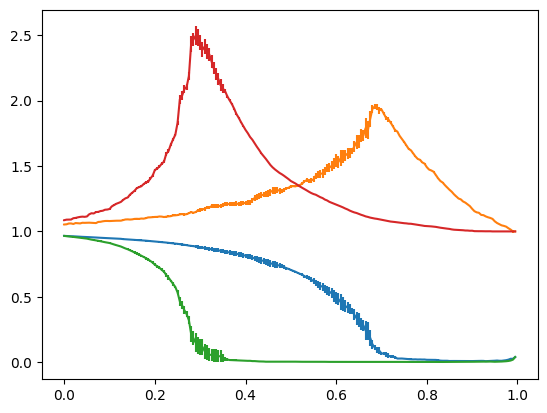

In [ ]:


plt.errorbar(f, S_rand_avg, yerr=S_rand_std)
plt.errorbar(f, s_rand_avg, yerr=S_rand_std)



S_att_all = np.array(S_att_all)   # shape = (N_runs, N_q)
s_att_all = np.array(s_att_all)

S_att_avg = np.mean(S_att_all, axis=0)
s_att_avg = np.mean(s_att_all, axis=0)

S_att_std = np.std(S_att_all, axis=0)
s_att_std = np.std(s_att_all, axis=0)

plt.errorbar(f, S_att_avg, yerr=S_att_std)
plt.errorbar(f, s_att_avg, yerr=S_att_std)



# **ATTACK HIGHEST k ON ERDOS-RENYI**

In [16]:
import random
import networkx as nx
import math
from time import time
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt

N = 5000
p = 0.0007
# since p_c goes like 1/N and we want to simulate an attack on a Gcc, 
# we will choose p>>1/n such that Gcc is present for sue and our "attack" will send us back to the disconnected phase

# f = 0.2

G = nx.erdos_renyi_graph(N, p)
f = []
S = []
s=[]
removed=0


for q in np.arange(0,1,0.005):

    ordered_nodes = [node for node, deg in sorted(G.degree,key=lambda x: x[1],reverse=True)]
    # build array of f = fraction of removed nodes
    f.append(q)
    print(q)

    # remove f*N nodes at random
    number_remno = int(q * N - removed)
    G.remove_nodes_from(ordered_nodes[:number_remno])
    removed = N - G.number_of_nodes()

    # calculates size of largest cluster S = (n° nodes in largest cluster) / (n° nodes in network)
    largest_cluster = max(nx.connected_components(G), key=len)
    S.append(len(largest_cluster) / G.number_of_nodes())
    s.append(s_avg(G))


plt.figure(1, figsize=(10, 6))
plt.scatter(f,S,s=30, marker="s",facecolors="none",edgecolors="blue", label="S attack")
plt.scatter(f,s,s=30, marker="s", facecolors="blue", label="<s> attack")
plt.xlabel("f")

plt.legend()

plt.show()

0.0
0.005
0.01
0.015
0.02
0.025
0.03
0.035
0.04
0.045
0.05
0.055
0.06
0.065


KeyboardInterrupt: 

# **RANDOM FAILURE vs ATTACK HIGHEST k ON Barabasi Albert MODEL**

0.0
0.005
0.01
0.015
0.02
0.025
0.03
0.035
0.04
0.045
0.05
0.055
0.06
0.065
0.07
0.075
0.08
0.085
0.09
0.095
0.1
0.105
0.11
0.115
0.12
0.125
0.13
0.135
0.14
0.145
0.15
0.155
0.16
0.165
0.17
0.17500000000000002
0.18
0.185
0.19
0.195
0.2
0.20500000000000002
0.21
0.215
0.22
0.225
0.23
0.23500000000000001
0.24
0.245
0.25
0.255
0.26
0.265
0.27
0.275
0.28
0.28500000000000003
0.29
0.295
0.3
0.305
0.31
0.315
0.32
0.325
0.33
0.335
0.34
0.34500000000000003
0.35000000000000003
0.355
0.36
0.365
0.37
0.375
0.38
0.385
0.39
0.395
0.4
0.405
0.41000000000000003
0.41500000000000004
0.42
0.425
0.43
0.435
0.44
0.445
0.45
0.455
0.46
0.465
0.47000000000000003
0.47500000000000003
0.48
0.485
0.49
0.495
0.5
0.505
0.51
0.515
0.52
0.525
0.53
0.535
0.54
0.545
0.55
0.555
0.56
0.5650000000000001
0.5700000000000001
0.5750000000000001
0.58
0.585
0.59
0.595
0.6
0.605
0.61
0.615
0.62
0.625
0.63
0.635
0.64
0.645
0.65
0.655
0.66
0.665
0.67
0.675
0.68
0.685
0.6900000000000001
0.6950000000000001
0.7000000000000001
0.705
0.

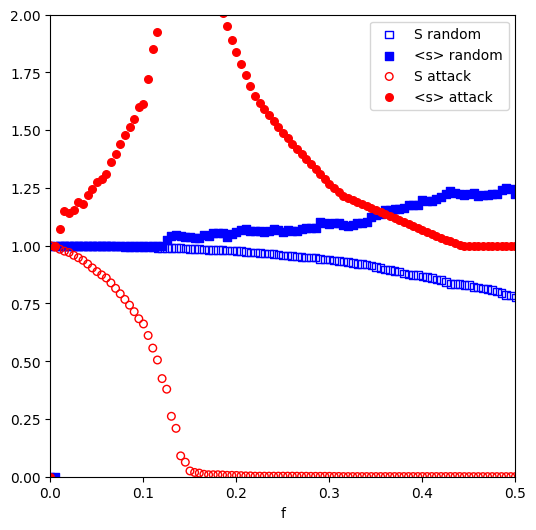

In [ ]:
N = 5000
m = 2   # each new node attaches to m existing nodes

BA_rand = nx.barabasi_albert_graph(N, m)
BA_att = nx.barabasi_albert_graph(N, m)

f = []
S_BA_rand = []
s_BA_rand = []
removed_rand = 0

S_BA_att = []
s_BA_att = []
removed_att = 0

for q in np.arange(0, 1, 0.005):

    print(q)
    f.append(q)
    
#### remove f*N nodes at RANDOM ####    
    number_remno = int(q * N - removed_rand)
    nodes_to_remove = random.sample(list(BA_rand.nodes()), number_remno)

    BA_rand.remove_nodes_from(nodes_to_remove)

    removed_rand = N - BA_rand.number_of_nodes()

    if BA_rand.number_of_nodes() > 0:
        largest_cluster = max(nx.connected_components(BA_rand), key=len)
        S_BA_rand.append(len(largest_cluster) / BA_rand.number_of_nodes())
    else:
        S.append(0)

    s_BA_rand.append(s_avg(BA_rand))


#### remove f*N nodes via ATTACK ####
    ordered_nodes = [node for node, deg in sorted(BA_att.degree,key=lambda x: x[1],reverse=True)]

    number_remno = int(q * N - removed_att)
    BA_att.remove_nodes_from(ordered_nodes[:number_remno])
    removed_att = N - BA_att.number_of_nodes()

    #print(len(nodes_to_remove), BA_att.number_of_nodes())

    if BA_att.number_of_nodes() > 0:
        largest_cluster = max(nx.connected_components(BA_att), key=len)
        S_BA_att.append(len(largest_cluster) / BA_att.number_of_nodes())
    else:
        S_BA_att.append(0)

    s_BA_att.append(s_avg(BA_att))


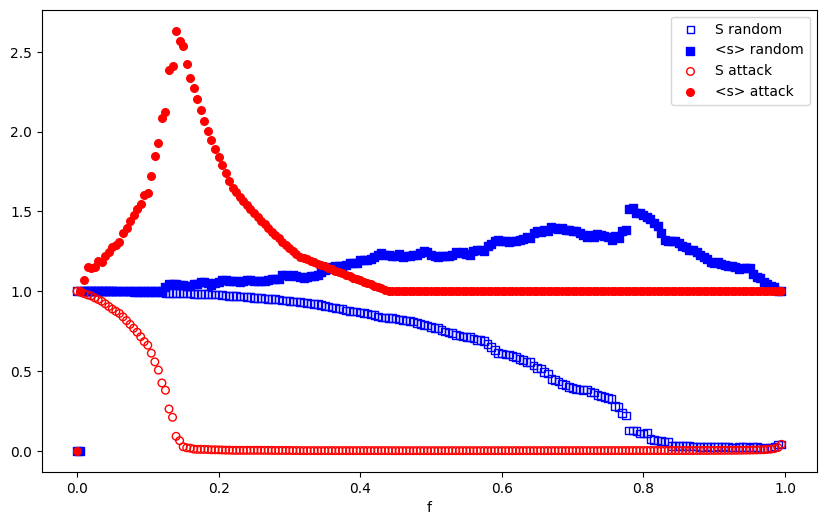

In [17]:
plt.figure(1, figsize=(10, 6))
plt.scatter(f,S_BA_rand,s=30, marker="s",facecolors="none",edgecolors="blue", label="S random")
plt.scatter(f,s_BA_rand,s=30, marker="s", facecolors="blue", label="<s> random")
plt.scatter(f,S_BA_att,s=30, marker="o",facecolors="none",edgecolors="red", label="S attack")
plt.scatter(f,s_BA_att,s=30, marker="o", facecolors="red", label="<s> attack")

# plt.ylim(0,3)
# plt.xlim(0,0.5)
plt.xlabel("f")

plt.legend()

plt.show()

# **ATTACK HIGHEST k ON BARABASI-ALBERT**

5000
25 5000
4975
25 4975
4950
25 4950
4925
25 4925
4900
25 4900
4875
25 4875
4850
25 4850
4825
25 4825
4800
25 4800
4775
25 4775
4750
25 4750
4725
25 4725
4700
25 4700
4675
25 4675
4650
25 4650
4625
25 4625
4600
25 4600
4575
25 4575
4550
25 4550
4525
25 4525
4500
25 4500
4475
25 4475
4450
25 4450
4425
25 4425
4400
25 4400
4375
25 4375
4350
25 4350
4325
25 4325
4300
25 4300
4275
25 4275
4250
25 4250
4225
25 4225
4200
25 4200
4175
25 4175
4150
25 4150
4125
25 4125
4100
25 4100
4075
25 4075
4050
25 4050
4025
25 4025
4000
25 4000
3975
25 3975
3950
25 3950
3925
25 3925
3900
25 3900
3875
25 3875
3850
25 3850
3825
25 3825
3800
25 3800
3775
25 3775
3750
25 3750
3725
25 3725
3700
25 3700
3675
25 3675
3650
25 3650
3625
25 3625
3600
25 3600
3575
25 3575
3550
25 3550
3525
25 3525
3500
25 3500
3475
25 3475
3450
25 3450
3425
25 3425
3400
25 3400
3375
25 3375
3350
25 3350
3325
25 3325
3300
25 3300
3275
25 3275
3250
25 3250
3225
25 3225
3200
25 3200
3175
25 3175
3150
25 3150
3125
25 3125
3100
25 3100

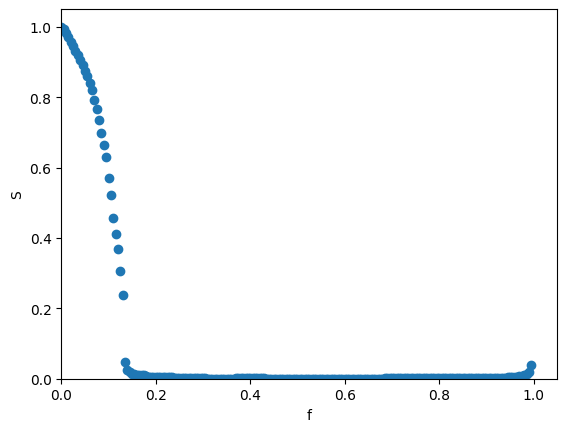

In [87]:
import random
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

N = 5000
m = 2   # each new node attaches to m existing nodes

G = nx.barabasi_albert_graph(N, m)

f = []
S = []
removed = 0

for q in np.arange(0, 1, 0.005):
    
    ordered_nodes = [node for node, deg in sorted(G.degree,key=lambda x: x[1],reverse=True)]
    f.append(q)

    number_remno = int(q * N - removed)
    G.remove_nodes_from(ordered_nodes[:number_remno])
    removed = N - G.number_of_nodes()
    print(G.number_of_nodes())

    print(len(nodes_to_remove), G.number_of_nodes())

    if G.number_of_nodes() > 0:
        largest_cluster = max(nx.connected_components(G), key=len)
        S.append(len(largest_cluster) / G.number_of_nodes())
    else:
        S.append(0)

plt.scatter(f, S)
plt.xlabel("f")
plt.ylabel("S")

plt.ylim(0,1.05)
plt.xlim(0,1.05)

plt.show()


# **RANDOM FAILURE vs ATTACK HOIGHEST k on ATTRACTIVENESS MODEL**

0.0
0.005
0.01
0.015
0.02
0.025
0.03
0.035
0.04
0.045
0.05
0.055
0.06
0.065
0.07
0.075
0.08
0.085
0.09
0.095
0.1
0.105
0.11
0.115
0.12
0.125
0.13
0.135
0.14
0.145
0.15
0.155
0.16
0.165
0.17
0.17500000000000002
0.18
0.185
0.19
0.195
0.2
0.20500000000000002
0.21
0.215
0.22
0.225
0.23
0.23500000000000001
0.24
0.245
0.25
0.255
0.26
0.265
0.27
0.275
0.28
0.28500000000000003
0.29
0.295
0.3
0.305
0.31
0.315
0.32
0.325
0.33
0.335
0.34
0.34500000000000003
0.35000000000000003
0.355
0.36
0.365
0.37
0.375
0.38
0.385
0.39
0.395
0.4
0.405
0.41000000000000003
0.41500000000000004
0.42
0.425
0.43
0.435
0.44
0.445
0.45
0.455
0.46
0.465
0.47000000000000003
0.47500000000000003
0.48
0.485
0.49
0.495
0.5
0.505
0.51
0.515
0.52
0.525
0.53
0.535
0.54
0.545
0.55
0.555
0.56
0.5650000000000001
0.5700000000000001
0.5750000000000001
0.58
0.585
0.59
0.595
0.6
0.605
0.61
0.615
0.62
0.625
0.63
0.635
0.64
0.645
0.65
0.655
0.66
0.665
0.67
0.675
0.68
0.685
0.6900000000000001
0.6950000000000001
0.7000000000000001
0.705
0.

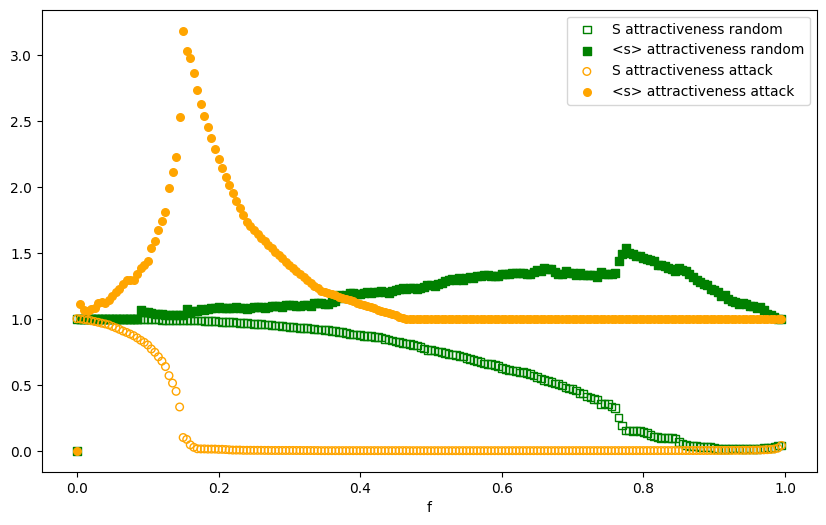

In [ ]:
def attractiveness_graph(N, m, a):

    G = nx.complete_graph(m)

    for new_node in range(m, N):

        nodes = list(G.nodes())
        weights = [G.degree(node) + a for node in nodes]

        targets = set()
        while len(targets) < m:
            targets.add(random.choices(nodes, weights=weights, k=1)[0])

        G.add_node(new_node)

        for target in targets:
            G.add_edge(new_node, target)

    return G


N = 5000
m = 2
a = 1

ATT_rand = attractiveness_graph(N, m, a)
ATT_att  = attractiveness_graph(N, m, a)

S_ATT_rand = []
s_ATT_rand = []
removed_rand = 0

S_ATT_att = []
s_ATT_att = []
removed_att = 0

for q in np.arange(0, 1, 0.005):

    print(q)

    #### remove f*N nodes at RANDOM ####
    number_remno = int(q * N - removed_rand)
    nodes_to_remove = random.sample(list(ATT_rand.nodes()), number_remno)

    ATT_rand.remove_nodes_from(nodes_to_remove)

    removed_rand = N - ATT_rand.number_of_nodes()

    if ATT_rand.number_of_nodes() > 0:
        largest_cluster = max(nx.connected_components(ATT_rand), key=len)
        S_ATT_rand.append(len(largest_cluster) / ATT_rand.number_of_nodes())
    else:
        S_ATT_rand.append(0)

    s_ATT_rand.append(s_avg(ATT_rand))

    #### remove f*N nodes via ATTACK ####
    ordered_nodes = [node for node, deg in sorted(
        ATT_att.degree,
        key=lambda x: x[1],
        reverse=True
    )]

    number_remno = int(q * N - removed_att)

    ATT_att.remove_nodes_from(ordered_nodes[:number_remno])

    removed_att = N - ATT_att.number_of_nodes()

    if ATT_att.number_of_nodes() > 0:
        largest_cluster = max(nx.connected_components(ATT_att), key=len)
        S_ATT_att.append(len(largest_cluster) / ATT_att.number_of_nodes())
    else:
        S_ATT_att.append(0)

    s_ATT_att.append(s_avg(ATT_att))


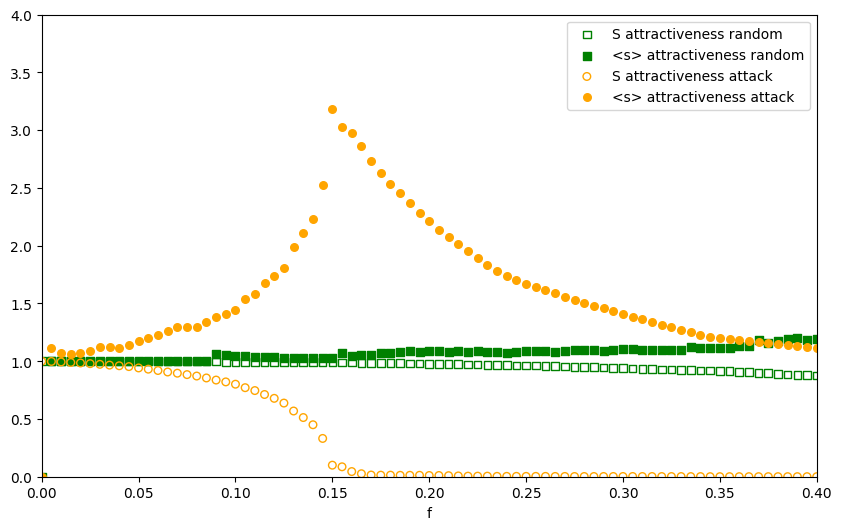

In [21]:
plt.figure(figsize=(10, 6))

plt.scatter(
    f, S_ATT_rand,
    s=30, marker="s",
    facecolors="none", edgecolors="green",
    label="S attractiveness random"
)

plt.scatter(
    f, s_ATT_rand,
    s=30, marker="s",
    facecolors="green",
    label="<s> attractiveness random"
)

plt.scatter(
    f, S_ATT_att,
    s=30, marker="o",
    facecolors="none", edgecolors="orange",
    label="S attractiveness attack"
)

plt.scatter(
    f, s_ATT_att,
    s=30, marker="o",
    facecolors="orange",
    label="<s> attractiveness attack"
)

plt.ylim(0,4)
plt.xlim(0,0.4)

plt.xlabel("f")
plt.legend()
plt.show()

5000
25 5000
4975
25 4975
4950
25 4950
4925
25 4925
4900
25 4900
4875
25 4875
4850
25 4850
4825
25 4825
4800
25 4800
4775
25 4775
4750
25 4750
4725
25 4725
4700
25 4700
4675
25 4675
4650
25 4650
4625
25 4625
4600
25 4600
4575
25 4575
4550
25 4550
4525
25 4525
4500
25 4500
4475
25 4475
4450
25 4450
4425
25 4425
4400
25 4400
4375
25 4375
4350
25 4350
4325
25 4325
4300
25 4300
4275
25 4275
4250
25 4250
4225
25 4225
4200
25 4200
4175
25 4175
4150
25 4150
4125
25 4125
4100
25 4100
4075
25 4075
4050
25 4050
4025
25 4025
4000
25 4000
3975
25 3975
3950
25 3950
3925
25 3925
3900
25 3900
3875
25 3875
3850
25 3850
3825
25 3825
3800
25 3800
3775
25 3775
3750
25 3750
3725
25 3725
3700
25 3700
3675
25 3675
3650
25 3650
3625
25 3625
3600
25 3600
3575
25 3575
3550
25 3550
3525
25 3525
3500
25 3500
3475
25 3475
3450
25 3450
3425
25 3425
3400
25 3400
3375
25 3375
3350
25 3350
3325
25 3325
3300
25 3300
3275
25 3275
3250
25 3250
3225
25 3225
3200
25 3200
3175
25 3175
3150
25 3150
3125
25 3125
3100
25 3100

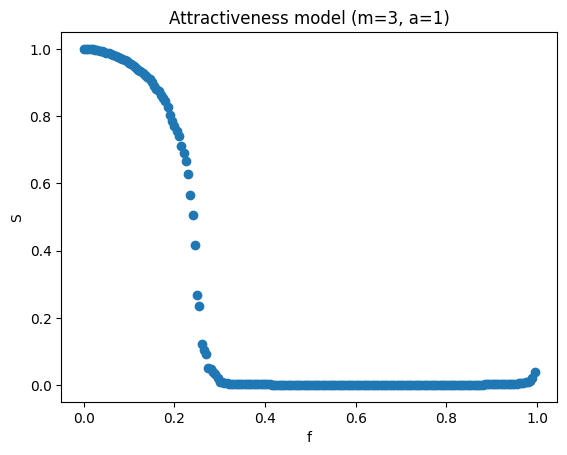

In [82]:
import random
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

def attractiveness_graph(N, m, a):

    G = nx.complete_graph(m)

    for new_node in range(m, N):

        nodes = list(G.nodes())
        weights = [G.degree(node) + a for node in nodes]

        targets = set()
        while len(targets) < m:
            targets.add(random.choices(nodes, weights=weights, k=1)[0])

        G.add_node(new_node)

        for target in targets:
            G.add_edge(new_node, target)

    return G


N = 5000
m = 3
a = 1

# Build attractiveness network
G = attractiveness_graph(N, m, a)

f = []
S = []
removed = 0

for q in np.arange(0, 1, 0.005):
    
    ordered_nodes = [node for node, deg in sorted(G.degree,key=lambda x: x[1],reverse=True)]
    f.append(q)

    number_remno = int(q * N - removed)
    G.remove_nodes_from(ordered_nodes[:number_remno])
    removed = N - G.number_of_nodes()
    print(G.number_of_nodes())


    print(len(nodes_to_remove), G.number_of_nodes())

    if G.number_of_nodes() > 0:
        largest_cluster = max(nx.connected_components(G), key=len)
        S.append(len(largest_cluster) / G.number_of_nodes())
    else:
        S.append(0)

plt.scatter(f, S)
plt.xlabel("f")
plt.ylabel("S")
plt.title(f"Attractiveness model (m={m}, a={a})")
plt.show()


0 5000
25 4975
25 4950
25 4925
25 4900
25 4875
25 4850
25 4825
25 4800
25 4775
25 4750
25 4725
25 4700
25 4675
25 4650
25 4625
25 4600
25 4575
25 4550
25 4525
25 4500
25 4475
25 4450
25 4425
25 4400
25 4375
25 4350
25 4325
25 4300
25 4275
25 4250
25 4225
25 4200
25 4175
25 4150
25 4125
25 4100
25 4075
25 4050
25 4025
25 4000
25 3975
25 3950
25 3925
25 3900
25 3875
25 3850
25 3825
25 3800
25 3775
25 3750
25 3725
25 3700
25 3675
25 3650
25 3625
25 3600
25 3575
25 3550
25 3525
25 3500
25 3475
25 3450
25 3425
25 3400
25 3375
25 3350
25 3325
25 3300
25 3275
25 3250
25 3225
25 3200
25 3175
25 3150
25 3125
25 3100
25 3075
25 3050
25 3025
25 3000
25 2975
25 2950
25 2925
25 2900
25 2875
25 2850
25 2825
25 2800
25 2775
25 2750
25 2725
25 2700
25 2675
25 2650
25 2625
25 2600
25 2575
25 2550
25 2525
25 2500
25 2475
25 2450
25 2425
25 2400
25 2375
25 2350
25 2325
25 2300
25 2275
25 2250
25 2225
25 2200
25 2175
25 2150
25 2125
25 2100
25 2075
25 2050
25 2025
25 2000
25 1975
25 1950
25 1925
25 1900
2

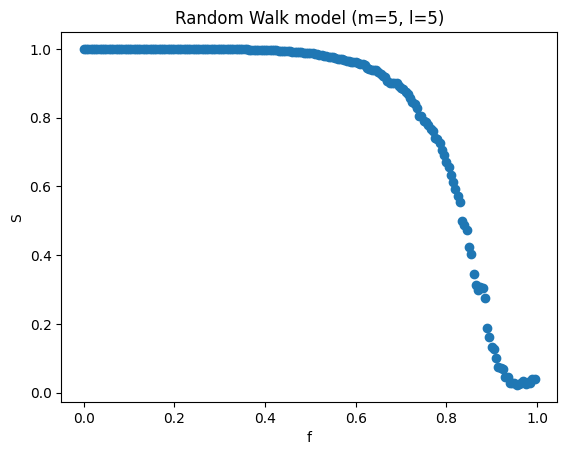

In [52]:
import random
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

def random_walk_graph(N, m, l):

    G = nx.complete_graph(m + 1)

    for new_node in range(m + 1, N):

        G.add_node(new_node)

        targets = set()

        while len(targets) < m:

            # start from an existing node (not the new isolated one)
            current = random.choice(list(range(new_node)))

            for _ in range(l):
                neighbors = list(G.neighbors(current))
                current = random.choice(neighbors)

            targets.add(current)

        for target in targets:
            G.add_edge(new_node, target)

    return G


N = 5000
m = 5
l = 5

G = random_walk_graph(N, m, l)

f = []
S = []
removed = 0

for q in np.arange(0, 1, 0.005):

    f.append(q)

    number_remno = int(q * N - removed)

    nodes_to_remove = random.sample(list(G.nodes()), number_remno)
    G.remove_nodes_from(nodes_to_remove)

    removed = N - G.number_of_nodes()

    print(len(nodes_to_remove), G.number_of_nodes())

    if G.number_of_nodes() > 0:
        largest_cluster = max(nx.connected_components(G), key=len)
        S.append(len(largest_cluster) / G.number_of_nodes())
    else:
        S.append(0)

plt.scatter(f, S)
plt.xlabel("f")
plt.ylabel("S")
plt.title(f"Random Walk model (m={m}, l={l})")
plt.show()

0.0
0.005
0.01
0.015
0.02
0.025
0.03
0.035
0.04
0.045
0.05
0.055
0.06
0.065
0.07
0.075
0.08
0.085
0.09
0.095
0.1
0.105
0.11
0.115
0.12
0.125
0.13
0.135
0.14
0.145
0.15
0.155
0.16
0.165
0.17
0.17500000000000002
0.18
0.185
0.19
0.195
0.2
0.20500000000000002
0.21
0.215
0.22
0.225
0.23
0.23500000000000001
0.24
0.245
0.25
0.255
0.26
0.265
0.27
0.275
0.28
0.28500000000000003
0.29
0.295
0.3
0.305
0.31
0.315
0.32
0.325
0.33
0.335
0.34
0.34500000000000003
0.35000000000000003
0.355
0.36
0.365
0.37
0.375
0.38
0.385
0.39
0.395
0.4
0.405
0.41000000000000003
0.41500000000000004
0.42
0.425
0.43
0.435
0.44
0.445
0.45
0.455
0.46
0.465
0.47000000000000003
0.47500000000000003
0.48
0.485
0.49
0.495
0.5
0.505
0.51
0.515
0.52
0.525
0.53
0.535
0.54
0.545
0.55
0.555
0.56
0.5650000000000001
0.5700000000000001
0.5750000000000001
0.58
0.585
0.59
0.595
0.6
0.605
0.61
0.615
0.62
0.625
0.63
0.635
0.64
0.645
0.65
0.655
0.66
0.665
0.67
0.675
0.68
0.685
0.6900000000000001
0.6950000000000001
0.7000000000000001
0.705
0.

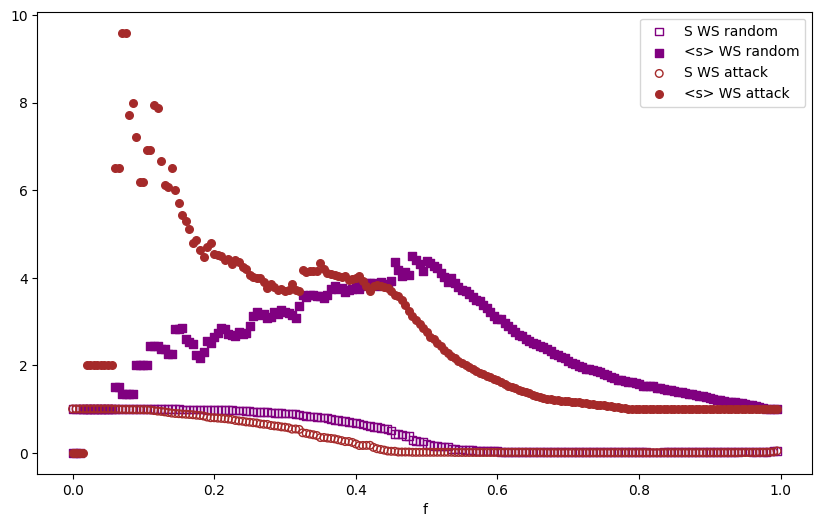

In [22]:
N = 5000
k = 4      # each node connected to k nearest neighbors
beta = 0.1 # rewiring probability

WS_rand = nx.watts_strogatz_graph(N, k, beta)
WS_att  = nx.watts_strogatz_graph(N, k, beta)

S_WS_rand = []
s_WS_rand = []
removed_rand = 0

S_WS_att = []
s_WS_att = []
removed_att = 0

for q in np.arange(0, 1, 0.005):

    print(q)

    #### remove f*N nodes at RANDOM ####
    number_remno = int(q * N - removed_rand)

    nodes_to_remove = random.sample(
        list(WS_rand.nodes()),
        number_remno
    )

    WS_rand.remove_nodes_from(nodes_to_remove)

    removed_rand = N - WS_rand.number_of_nodes()

    if WS_rand.number_of_nodes() > 0:
        largest_cluster = max(nx.connected_components(WS_rand), key=len)
        S_WS_rand.append(
            len(largest_cluster) / WS_rand.number_of_nodes()
        )
    else:
        S_WS_rand.append(0)

    s_WS_rand.append(s_avg(WS_rand))

    #### remove f*N nodes via ATTACK ####
    ordered_nodes = [node for node, deg in sorted(
        WS_att.degree,
        key=lambda x: x[1],
        reverse=True
    )]

    number_remno = int(q * N - removed_att)

    WS_att.remove_nodes_from(ordered_nodes[:number_remno])

    removed_att = N - WS_att.number_of_nodes()

    if WS_att.number_of_nodes() > 0:
        largest_cluster = max(nx.connected_components(WS_att), key=len)
        S_WS_att.append(
            len(largest_cluster) / WS_att.number_of_nodes()
        )
    else:
        S_WS_att.append(0)

    s_WS_att.append(s_avg(WS_att))


plt.figure(figsize=(10, 6))

plt.scatter(
    f, S_WS_rand,
    s=30, marker="s",
    facecolors="none", edgecolors="purple",
    label="S WS random"
)

plt.scatter(
    f, s_WS_rand,
    s=30, marker="s",
    facecolors="purple",
    label="<s> WS random"
)

plt.scatter(
    f, S_WS_att,
    s=30, marker="o",
    facecolors="none", edgecolors="brown",
    label="S WS attack"
)

plt.scatter(
    f, s_WS_att,
    s=30, marker="o",
    facecolors="brown",
    label="<s> WS attack"
)

plt.xlabel("f")
plt.legend()
plt.show()